# Exploratory Data Analysis — Security Feature Matrix

This notebook explores the feature matrix produced by `feature_extractor.py`
(`sample_features.csv`, user-hour window) for the Advanced Track Assignment 3.

Covers:
- Distribution of each engineered feature (histograms, boxplots)
- Correlation heatmap across numeric features
- A simple feature-importance proxy, since this synthetic dataset has no
  ground-truth attack labels (see the note in that section)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("sample_features.csv")
df.head()


,window_id,entity_id,entity_label,hour,hour_of_day,login_success_count,login_failure_count,unique_source_ips,failure_ratio,success_rate,time_since_last_login_min,is_business_hours,dns_query_entropy,domain_length,bytes_transferred,unique_dest_ports,peer_deviation,privacy_risk,login_failure_count_rolling_4h,login_success_count_rolling_4h,bytes_transferred_rolling_4h
0,2026-07-20_09_ps_ba91f0aa805d2926,ps_ba91f0aa805d2926,dave,2026-07-20_09,9,6,0,1,0.0,1.0,9.250000,True,0.0,0.0,0.0,0,-1.224745,HIGH,0.0,6.0,0.0
1,2026-07-20_10_ps_ba91f0aa805d2926,ps_ba91f0aa805d2926,dave,2026-07-20_10,10,4,1,1,0.2,0.8,12.286667,True,0.0,0.0,0.0,0,0.500000,HIGH,1.0,10.0,0.0
2,2026-07-20_11_ps_ba91f0aa805d2926,ps_ba91f0aa805d2926,dave,2026-07-20_11,11,2,0,1,0.0,1.0,15.050000,True,0.0,0.0,0.0,0,-0.719874,HIGH,1.0,12.0,0.0
3,2026-07-20_12_ps_ba91f0aa805d2926,ps_ba91f0aa805d2926,dave,2026-07-20_12,12,2,0,1,0.0,1.0,36.150000,True,0.0,0.0,0.0,0,-0.500000,HIGH,1.0,14.0,0.0
4,2026-07-20_13_ps_ba91f0aa805d2926,ps_ba91f0aa805d2926,dave,2026-07-20_13,13,2,0,1,0.0,1.0,16.358333,True,0.0,0.0,0.0,0,-0.500000,HIGH,1.0,10.0,0.0


## 1. Basic shape and summary statistics

In [2]:
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"Unique entities (pseudonymized): {df['entity_id'].nunique()}")
print(f"Hour buckets: {df['hour'].nunique()}")
df.describe(include=[np.number]).T


Rows: 30, Columns: 21
Unique entities (pseudonymized): 5
Hour buckets: 6


,count,mean,std,min,25%,50%,75%,max
hour_of_day,30.0,11.500000,1.737021,9.0,10.000000,11.500000,13.000000,14.000
login_success_count,30.0,3.200000,1.399507,1.0,2.000000,3.000000,4.000000,6.000
login_failure_count,30.0,1.033333,2.189053,0.0,0.000000,1.000000,1.000000,12.000
unique_source_ips,30.0,1.033333,0.182574,1.0,1.000000,1.000000,1.000000,2.000
failure_ratio,30.0,0.185000,0.213094,0.0,0.000000,0.166667,0.333333,0.800
success_rate,30.0,0.815000,0.213094,0.2,0.666667,0.833333,1.000000,1.000
time_since_last_login_min,30.0,16.662463,10.136439,3.6,10.041667,12.599167,19.268750,38.425
dns_query_entropy,30.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000
domain_length,30.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000
bytes_transferred,30.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000


## 2. Feature distributions (histograms)\n\nCount-style features are right-skewed as expected for security telemetry (most windows are quiet, a few are very active).

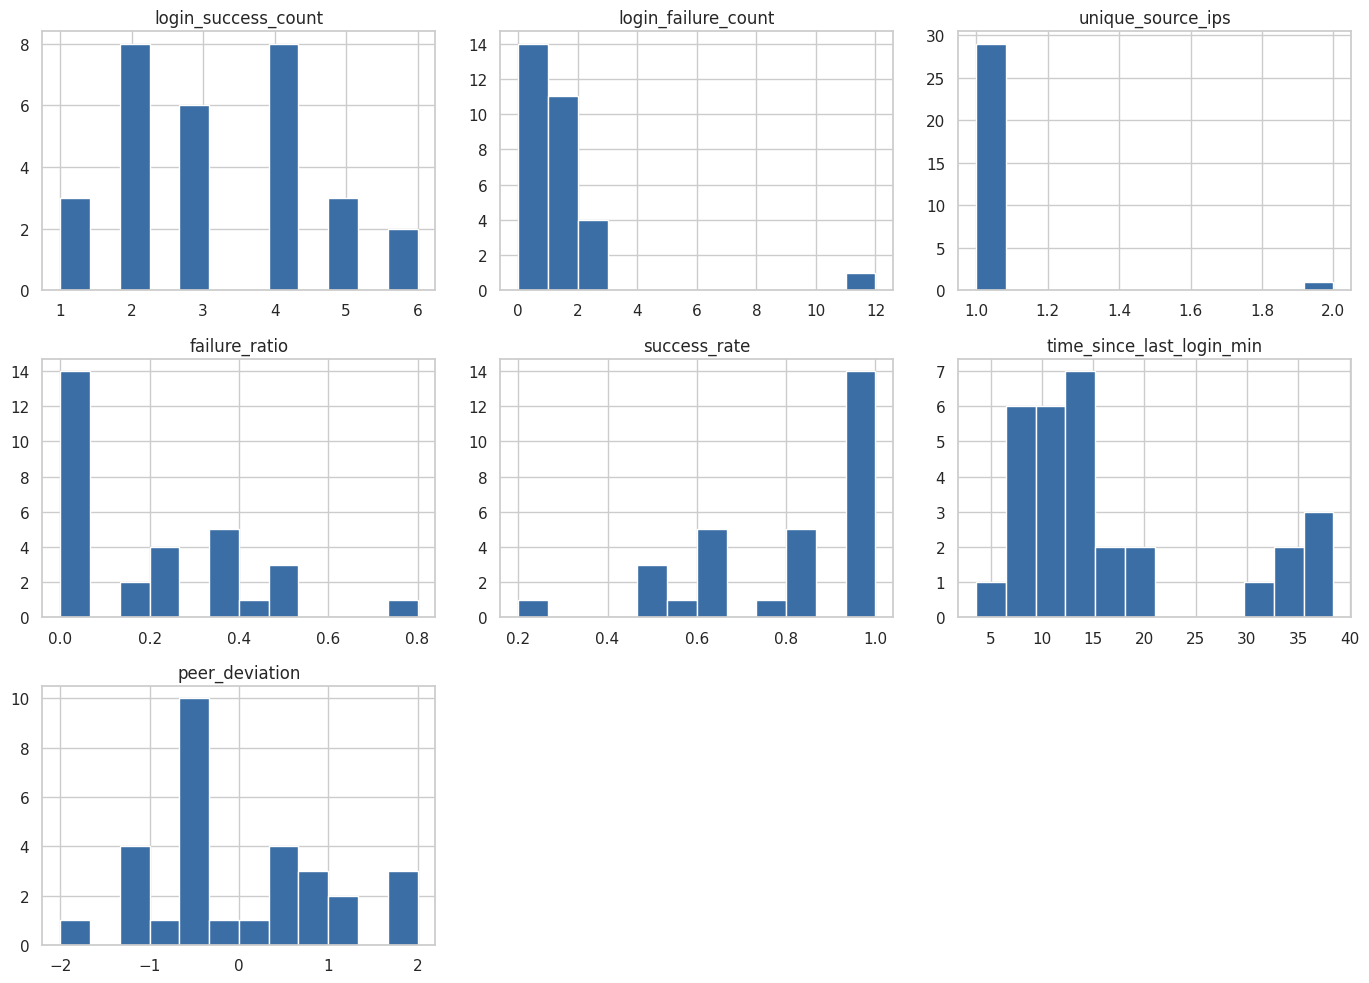

In [3]:
numeric_features = [
    "login_success_count", "login_failure_count", "unique_source_ips",
    "failure_ratio", "success_rate", "time_since_last_login_min",
    "peer_deviation",
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=12, color="#3b6ea5", edgecolor="white")
    axes[i].set_title(col)
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("eda_histograms.png", dpi=100)
plt.show()


## 3. Boxplots per feature\n\nBoxplots make outliers easier to spot than histograms alone — e.g. the brute-force burst shows up as a clear outlier point above the whisker for `login_failure_count`.

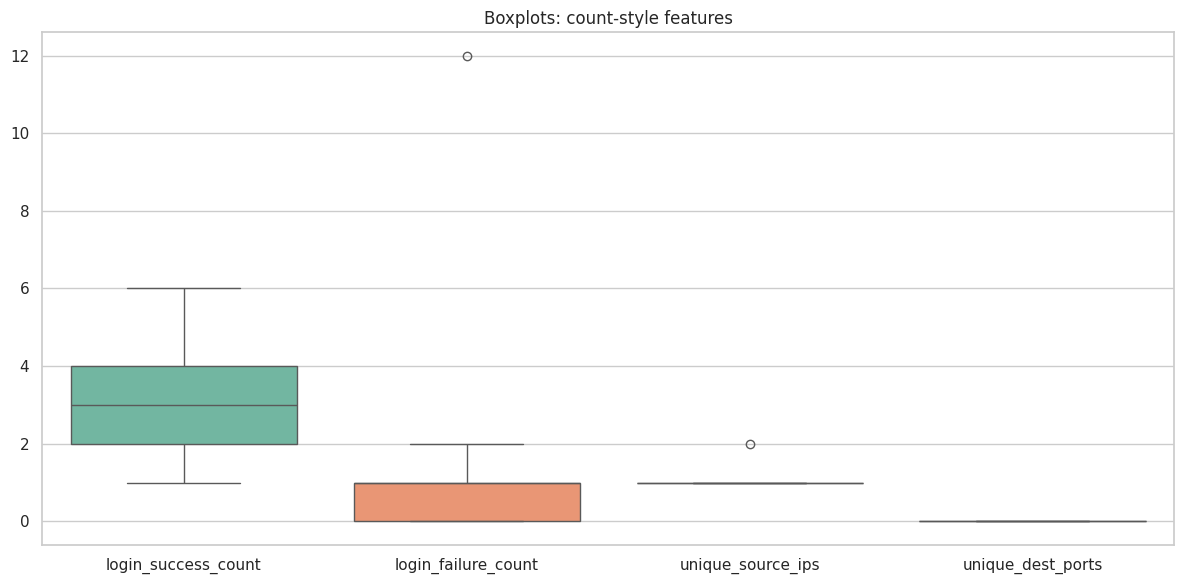

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = df[["login_success_count", "login_failure_count", "unique_source_ips",
              "unique_dest_ports"]]
sns.boxplot(data=plot_df, ax=ax, palette="Set2")
ax.set_title("Boxplots: count-style features")
plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=100)
plt.show()


## 4. Correlation heatmap

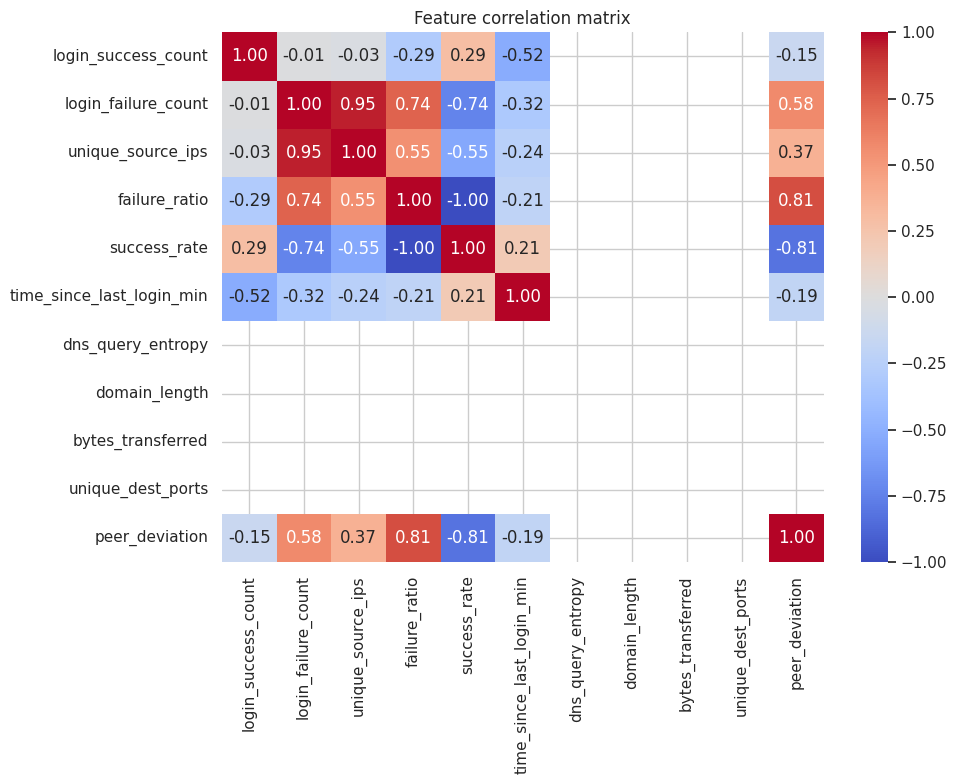

In [5]:
corr_features = [
    "login_success_count", "login_failure_count", "unique_source_ips",
    "failure_ratio", "success_rate", "time_since_last_login_min",
    "dns_query_entropy", "domain_length", "bytes_transferred",
    "unique_dest_ports", "peer_deviation",
]
corr = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=100)
plt.show()


## 5. Feature importance (proxy analysis)

This synthetic dataset has no ground-truth "is this an attack" label, so a
real supervised feature-importance ranking (e.g. from a trained classifier)
isn't possible yet — that's planned for the "supervised baseline next week"
mentioned in the assignment brief.

As a proxy, we treat `login_failure_count` as a stand-in target (since the
brute-force burst is the one clearly anomalous pattern injected into this
sample data) and rank the other features by their absolute correlation with
it. This is **not** a substitute for real feature importance — it only
shows which features move together with the one anomaly we know is in this
sample, and should be read as an EDA sanity check, not a modeling result.


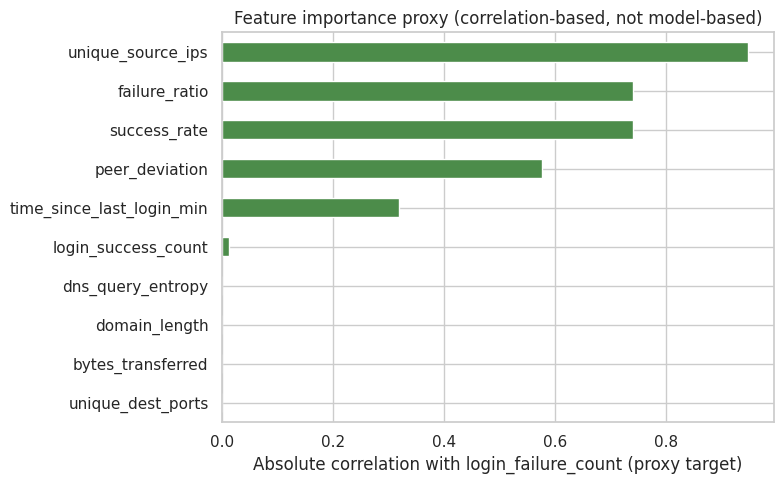

unique_source_ips            0.946196
failure_ratio                0.740331
success_rate                 0.740331
peer_deviation               0.575329
time_since_last_login_min    0.319201
login_success_count          0.013507
dns_query_entropy                 NaN
domain_length                     NaN
bytes_transferred                 NaN
unique_dest_ports                 NaN
Name: login_failure_count, dtype: float64

In [6]:
target = "login_failure_count"
candidate_features = [c for c in corr_features if c != target]

importance_proxy = (
    df[candidate_features + [target]].corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
importance_proxy.plot(kind="barh", ax=ax, color="#4c8c4a")
ax.set_xlabel("Absolute correlation with login_failure_count (proxy target)")
ax.set_title("Feature importance proxy (correlation-based, not model-based)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("eda_feature_importance_proxy.png", dpi=100)
plt.show()

importance_proxy


## 6. Observations

- `failure_ratio` and `success_rate` are, as expected, almost perfectly
  (anti-)correlated with `login_failure_count` / `login_success_count` by
  construction, since they're derived from the same counts.
- `peer_deviation` shows the clearest separation for the injected
  brute-force burst (carol's anomalous hour), which matches its intended
  purpose as a peer-comparison anomaly signal.
- `dns_query_entropy`, `domain_length`, `bytes_transferred`, and
  `unique_dest_ports` are all 0 in the **user-hour** window shown here,
  because NETWORK and DNS events don't carry a username in this dataset —
  see `feature_dictionary.md`. Re-running with `--window host-hour` would
  populate those columns instead.
